In [16]:
import pandas as pd

In [17]:
data = pd.read_csv("C:/Users/katik/Downloads/Aqueduct40_baseline_monthly_y2023m07d05.csv")

In [18]:
data.columns

Index(['pfaf_id', 'bws_01_raw', 'bws_01_score', 'bws_01_cat', 'bws_01_label',
       'bwd_01_raw', 'bwd_01_score', 'bwd_01_cat', 'bwd_01_label',
       'iav_01_raw',
       ...
       'bws_12_cat', 'bws_12_label', 'bwd_12_raw', 'bwd_12_score',
       'bwd_12_cat', 'bwd_12_label', 'iav_12_raw', 'iav_12_score',
       'iav_12_cat', 'iav_12_label'],
      dtype='object', length=145)

In [19]:
data.shape

(15834, 145)

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15834 entries, 0 to 15833
Columns: 145 entries, pfaf_id to iav_12_label
dtypes: float64(108), int64(1), object(36)
memory usage: 17.5+ MB


In [21]:
# Setting options to display all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Print the full list of columns
print(data.columns.tolist())

['pfaf_id', 'bws_01_raw', 'bws_01_score', 'bws_01_cat', 'bws_01_label', 'bwd_01_raw', 'bwd_01_score', 'bwd_01_cat', 'bwd_01_label', 'iav_01_raw', 'iav_01_score', 'iav_01_cat', 'iav_01_label', 'bws_02_raw', 'bws_02_score', 'bws_02_cat', 'bws_02_label', 'bwd_02_raw', 'bwd_02_score', 'bwd_02_cat', 'bwd_02_label', 'iav_02_raw', 'iav_02_score', 'iav_02_cat', 'iav_02_label', 'bws_03_raw', 'bws_03_score', 'bws_03_cat', 'bws_03_label', 'bwd_03_raw', 'bwd_03_score', 'bwd_03_cat', 'bwd_03_label', 'iav_03_raw', 'iav_03_score', 'iav_03_cat', 'iav_03_label', 'bws_04_raw', 'bws_04_score', 'bws_04_cat', 'bws_04_label', 'bwd_04_raw', 'bwd_04_score', 'bwd_04_cat', 'bwd_04_label', 'iav_04_raw', 'iav_04_score', 'iav_04_cat', 'iav_04_label', 'bws_05_raw', 'bws_05_score', 'bws_05_cat', 'bws_05_label', 'bwd_05_raw', 'bwd_05_score', 'bwd_05_cat', 'bwd_05_label', 'iav_05_raw', 'iav_05_score', 'iav_05_cat', 'iav_05_label', 'bws_06_raw', 'bws_06_score', 'bws_06_cat', 'bws_06_label', 'bwd_06_raw', 'bwd_06_score'

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Basic info
print(data.shape)
print(data.info())
print(data.describe().T)

# Missing values analysis
missing_vals = data.isnull().sum()
print("Missing values per column:\n", missing_vals)

# Listing columns by type
raw_cols = [c for c in data.columns if '_raw' in c]
score_cols = [c for c in data.columns if '_score' in c]
cat_cols = [c for c in data.columns if '_cat' in c]
label_cols = [c for c in data.columns if '_label' in c]




(15834, 145)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15834 entries, 0 to 15833
Columns: 145 entries, pfaf_id to iav_12_label
dtypes: float64(108), int64(1), object(36)
memory usage: 17.5+ MB
None
                count           mean            std       min            25%  \
pfaf_id       15834.0  432691.149994  225659.827126  111011.0  227621.250000   
bws_01_raw    15834.0     257.274279    1582.362945       0.0       0.000206   
bws_01_score  15834.0       1.355184       2.073783       0.0       0.000000   
bws_01_cat    15834.0       0.160920       1.102410      -1.0       0.000000   
bwd_01_raw    15834.0     257.230218    1582.370064       0.0       0.000103   
bwd_01_score  15834.0       1.268107       2.001341       0.0       0.002059   
bwd_01_cat    15834.0       0.050903       0.927791      -1.0       0.000000   
iav_01_raw    15834.0    -203.974983    1415.747869   -9999.0       0.282644   
iav_01_score  15834.0    -202.437372    1415.970590   -9999.0       1.1305

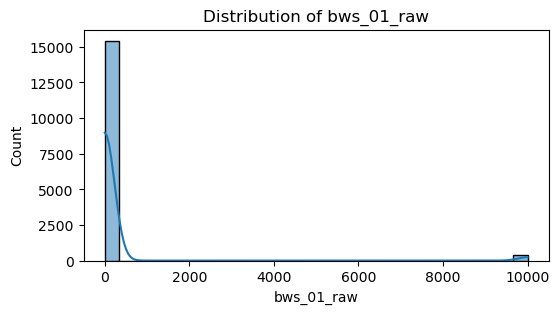

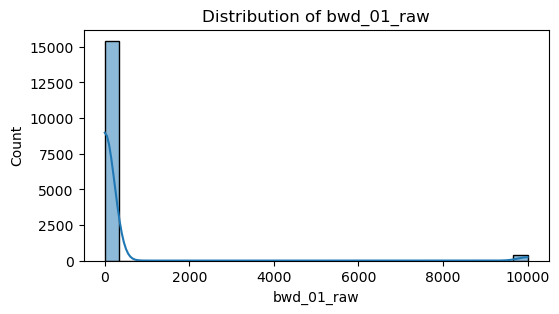

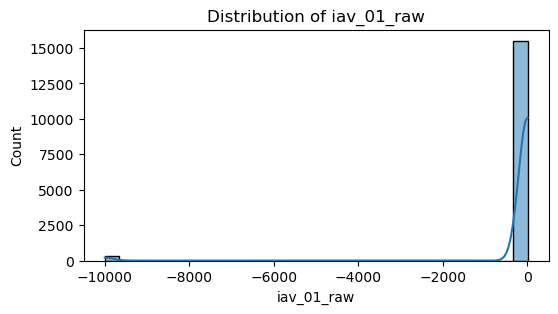

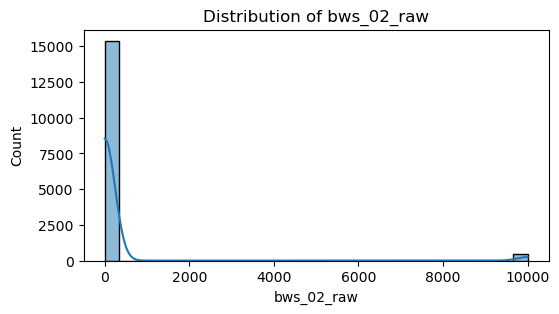

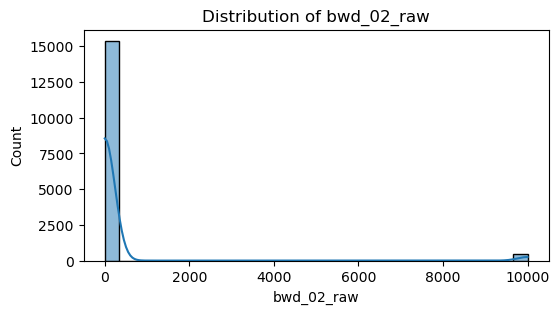

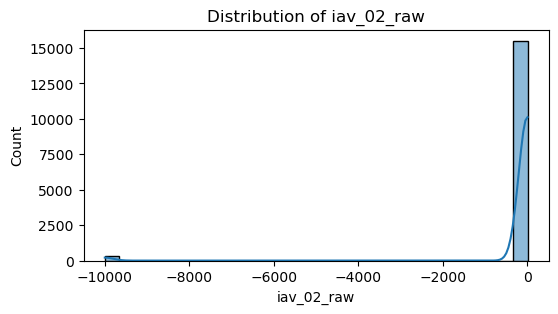

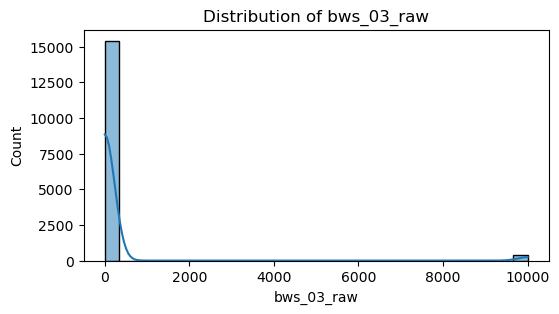

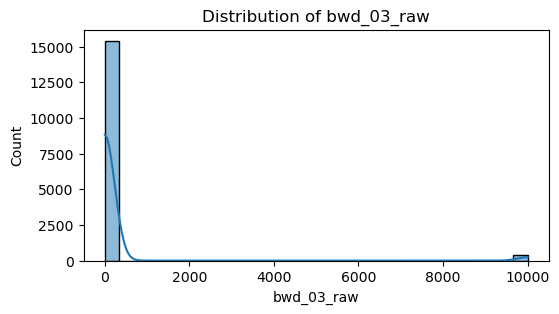

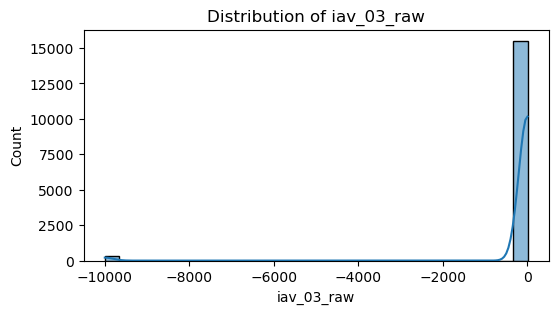

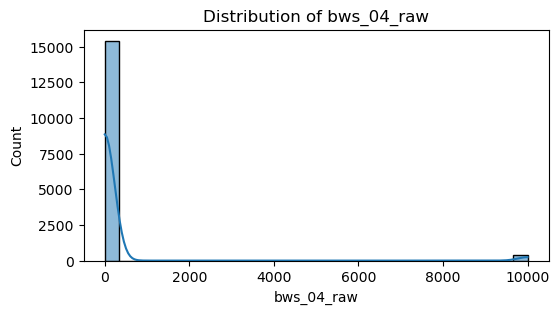

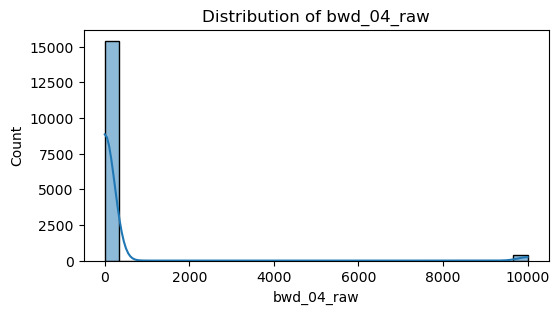

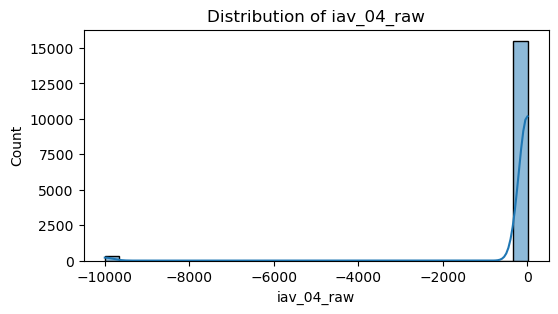

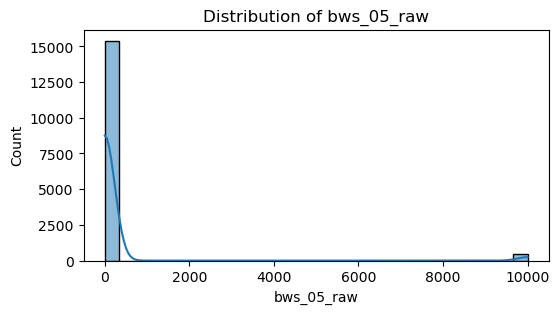

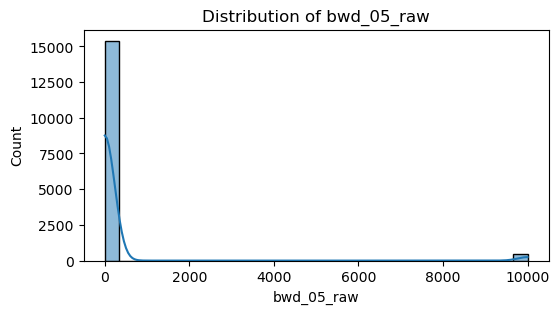

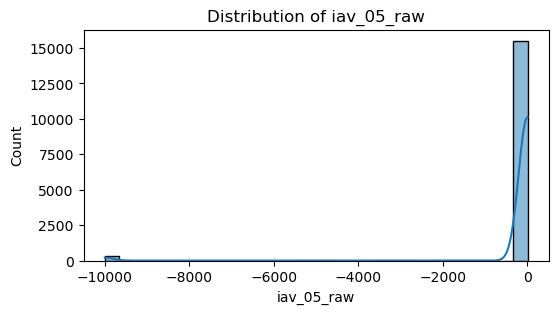

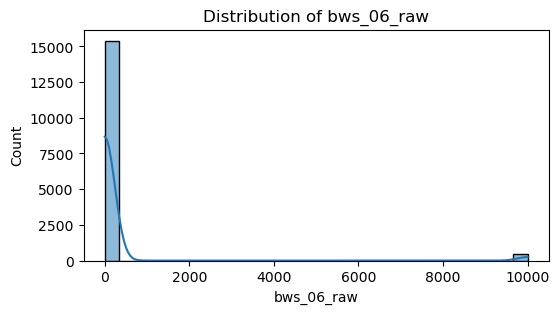

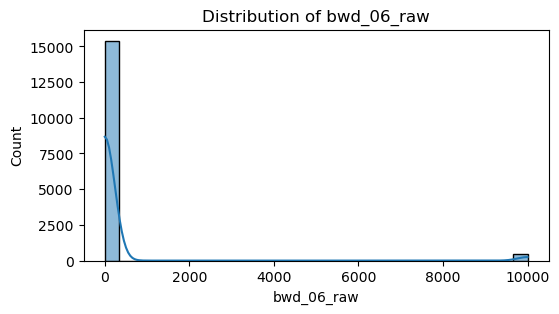

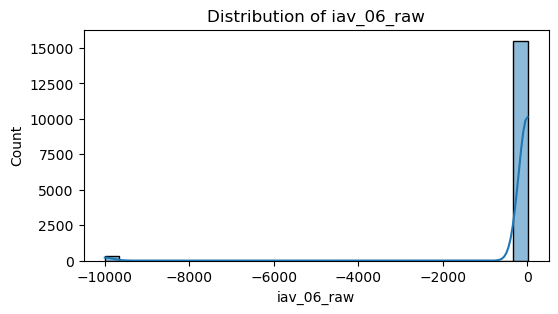

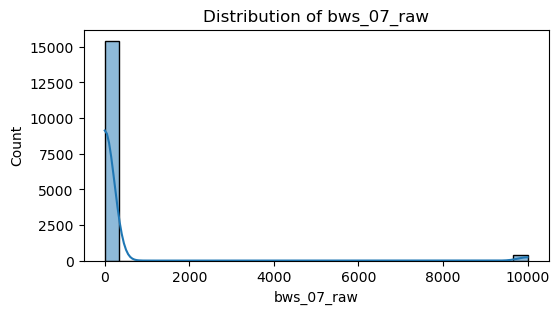

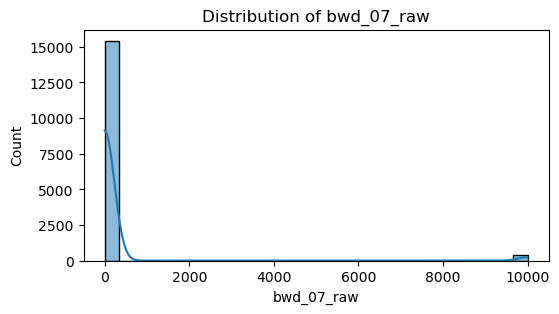

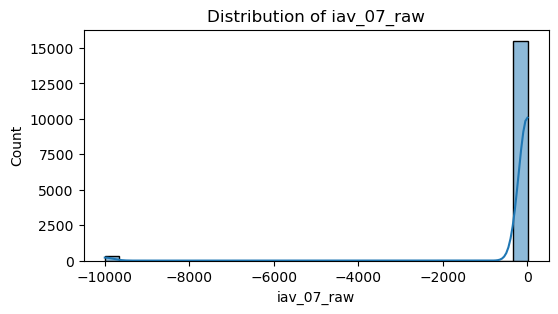

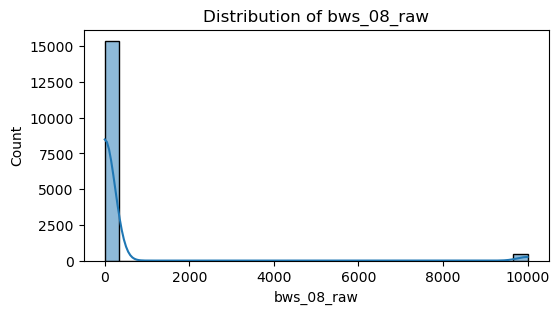

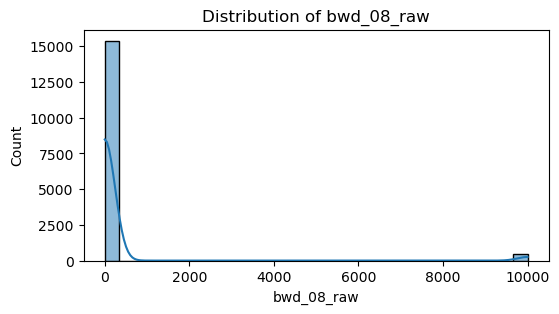

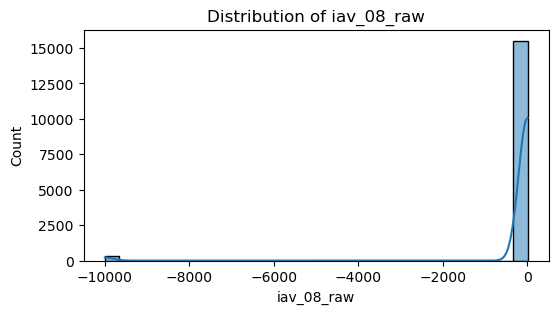

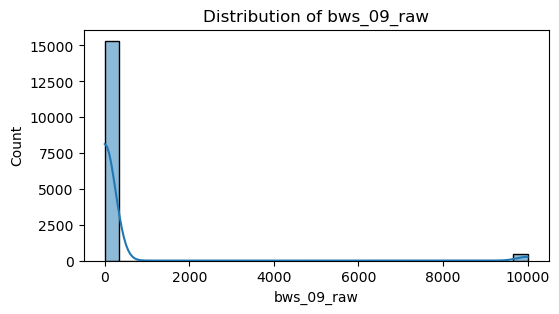

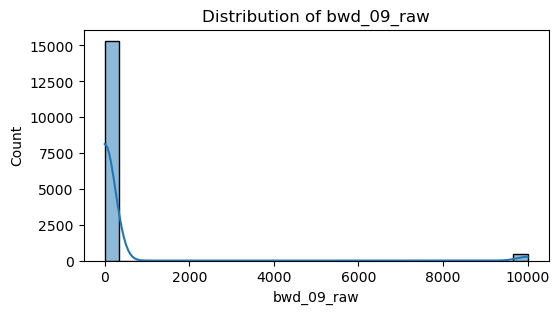

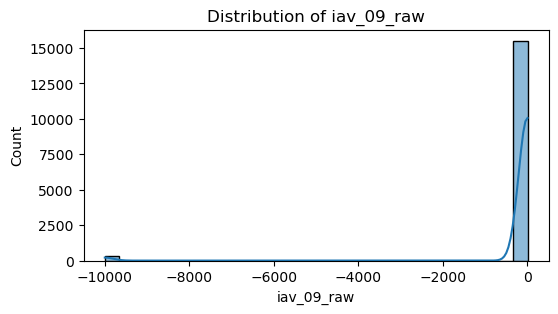

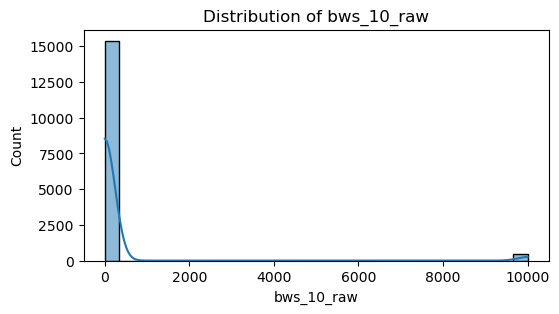

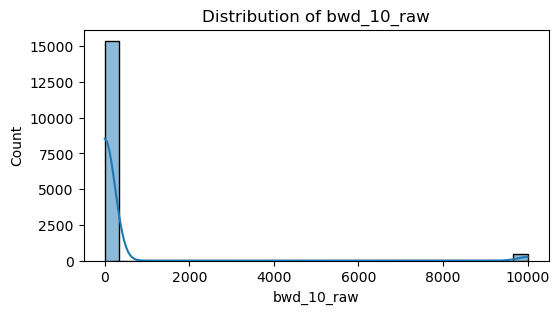

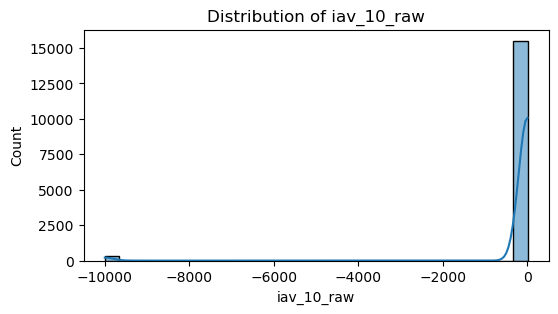

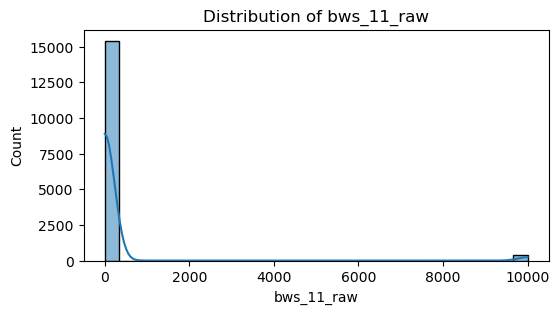

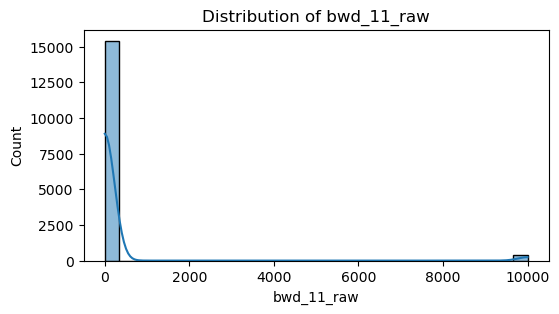

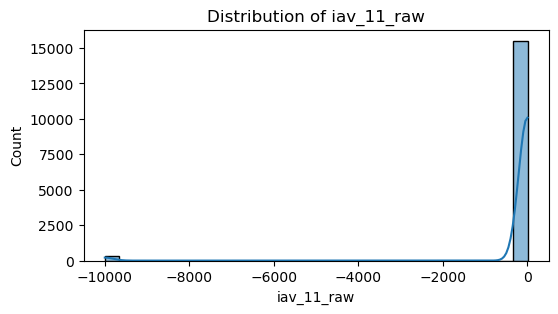

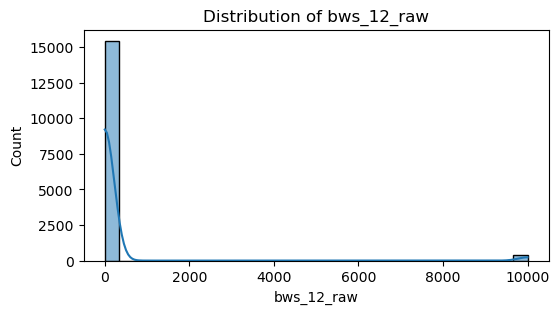

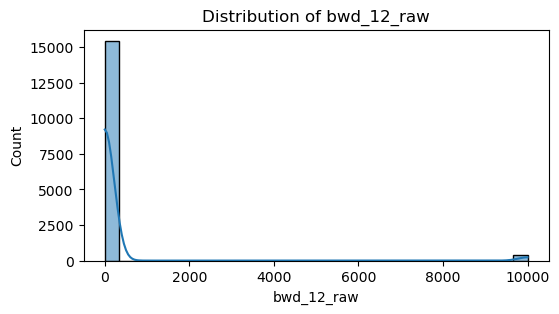

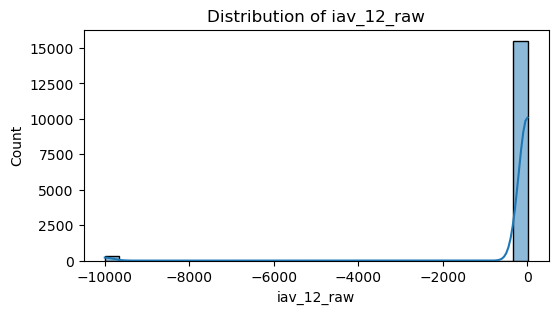

In [25]:
# Visualizing raw value distributions
for col in raw_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(data[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()


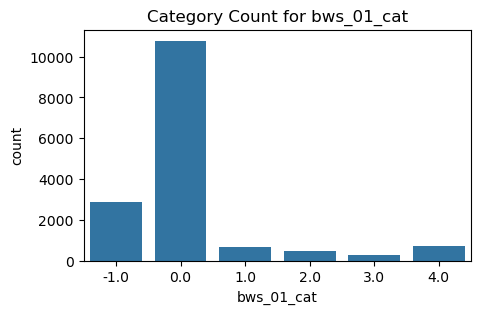

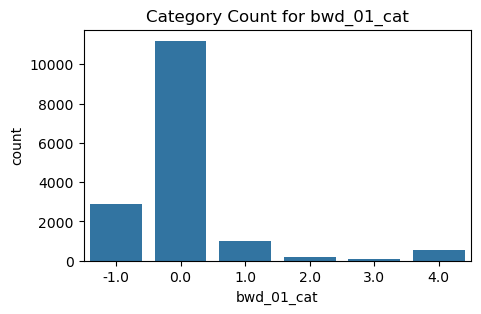

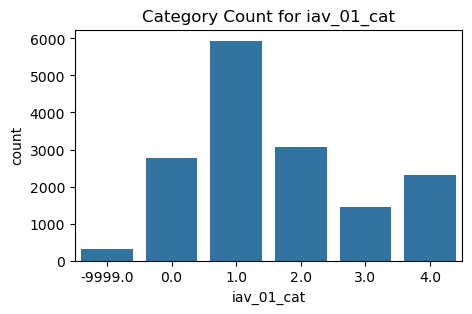

In [26]:
# Category counts (bar chart) for first month of each indicator
for ind in ['bws', 'bwd', 'iav']:
    cat_col = f'{ind}_01_cat'
    plt.figure(figsize=(5, 3))
    sns.countplot(x=data[cat_col])
    plt.title(f'Category Count for {cat_col}')
    plt.show()

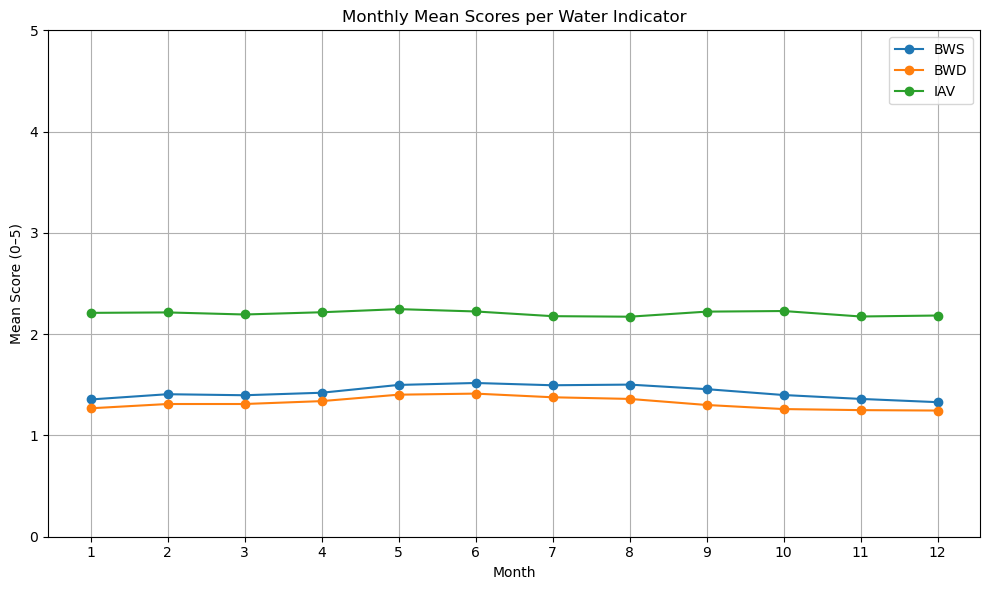

In [27]:
monthly_avg = {}

# Cleaning negative/invalid values and clamp scores to [0, 5]
for ind in ['bws', 'bwd', 'iav']:
    monthly_means = []
    for i in range(1, 13):
        col = f'{ind}_{str(i).zfill(2)}_score'
        values = data[col].dropna()
        # Filter: scores should be between 0 and 5
        clean_values = values[(values >= 0) & (values <= 5)]
        mean_score = clean_values.mean() if not clean_values.empty else np.nan
        monthly_means.append(mean_score)
    monthly_avg[ind] = monthly_means

plt.figure(figsize=(10, 6))

for ind in ['bws', 'bwd', 'iav']:
    plt.plot(range(1, 13), monthly_avg[ind], marker='o', label=ind.upper())

plt.xlabel('Month')
plt.ylabel('Mean Score (0–5)')
plt.title('Monthly Mean Scores per Water Indicator')
plt.ylim(0, 5)
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\katik\AppData\Local\Temp\ipykernel_46948\1561790692.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  valid_scores = data[score_months].applymap(lambda x: x if (pd.notna(x) and 0 <= x <= 5) else np.nan)


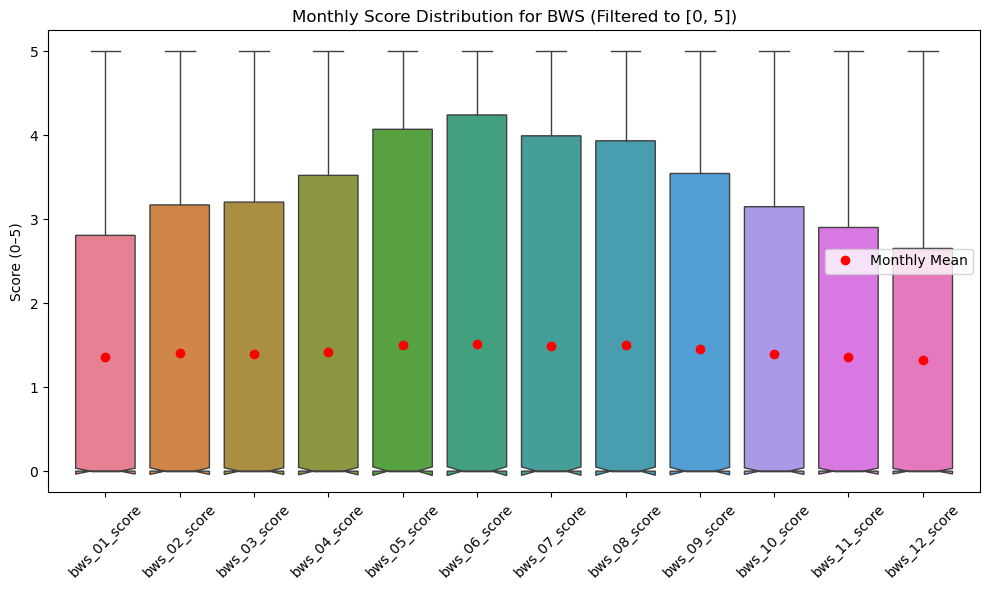

C:\Users\katik\AppData\Local\Temp\ipykernel_46948\1561790692.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  valid_scores = data[score_months].applymap(lambda x: x if (pd.notna(x) and 0 <= x <= 5) else np.nan)


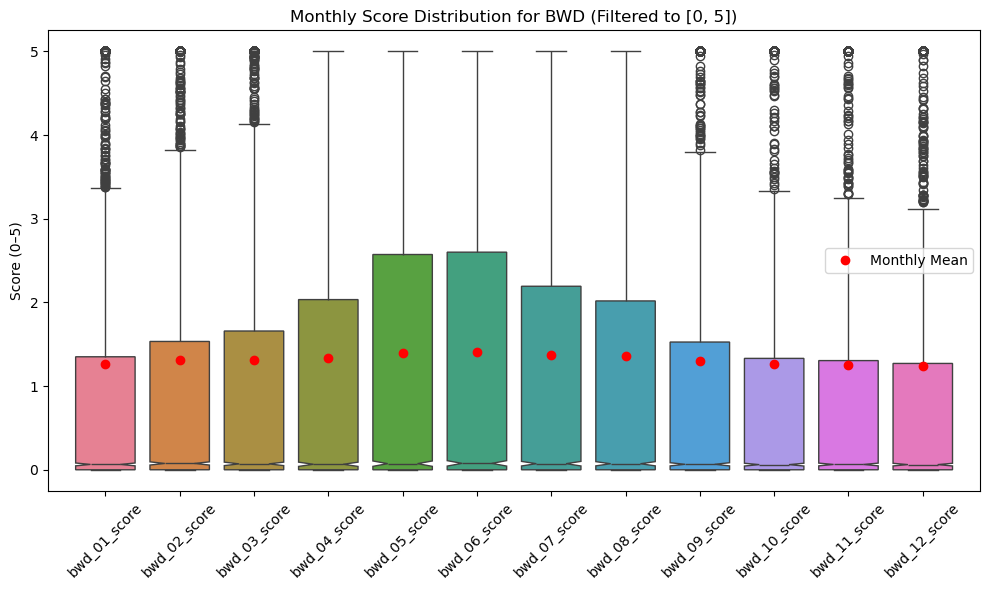

C:\Users\katik\AppData\Local\Temp\ipykernel_46948\1561790692.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  valid_scores = data[score_months].applymap(lambda x: x if (pd.notna(x) and 0 <= x <= 5) else np.nan)


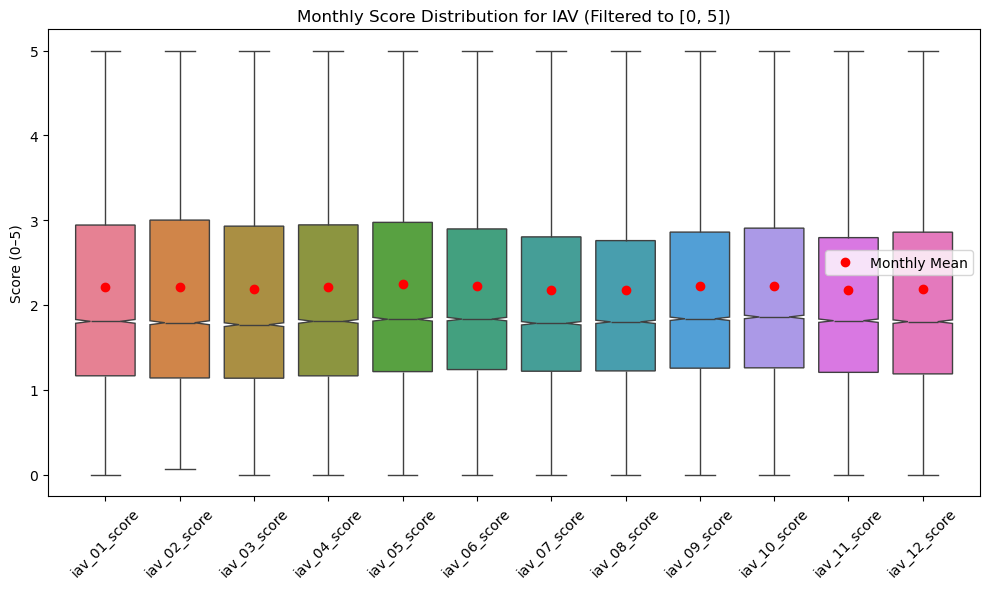

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

for ind in ['bws', 'bwd', 'iav']:
    score_months = [f'{ind}_{str(i).zfill(2)}_score' for i in range(1, 13)]
    # Filter scores to valid range [0, 5], replace out-of-range with NaN
    valid_scores = data[score_months].applymap(lambda x: x if (pd.notna(x) and 0 <= x <= 5) else np.nan)
    
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=valid_scores, showfliers=True, notch=True)
    plt.title(f'Monthly Score Distribution for {ind.upper()} (Filtered to [0, 5])')
    plt.ylabel('Score (0–5)')
    plt.xticks(rotation=45)
    
    # Optionally, add mean marker for each box
    means = valid_scores.mean()
    plt.plot(range(len(means)), means, color='red', marker='o', linestyle='', label='Monthly Mean')
    plt.legend()
    plt.tight_layout()
    plt.show()


C:\Users\katik\AppData\Local\Temp\ipykernel_46948\1767162273.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  valid_scores = data[score_months].applymap(lambda x: x if (pd.notna(x) and 0 <= x <= 5) else np.nan)


Displaying Monthly Score Distribution for BWS...


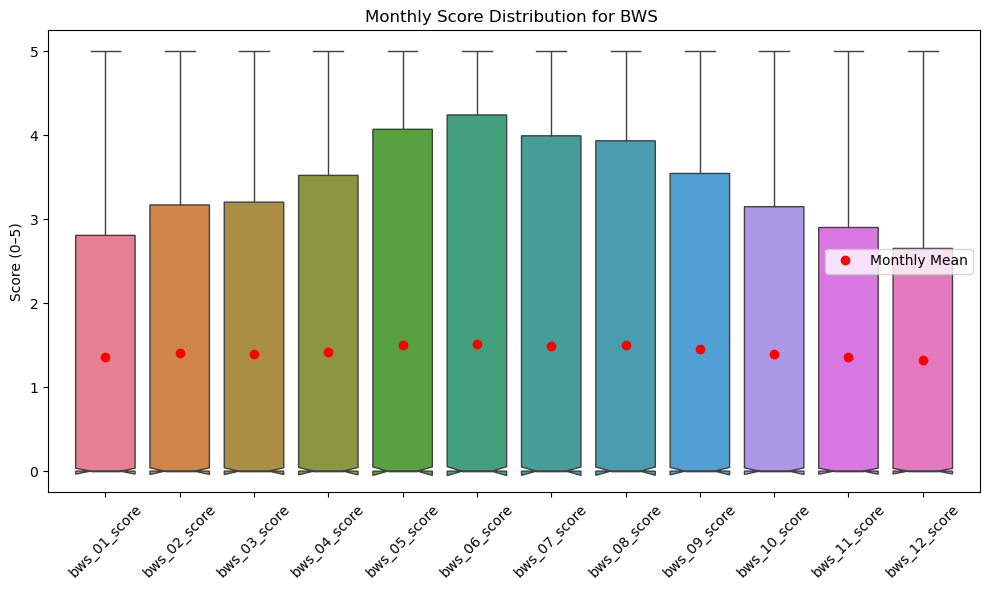

C:\Users\katik\AppData\Local\Temp\ipykernel_46948\1767162273.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  valid_scores = data[score_months].applymap(lambda x: x if (pd.notna(x) and 0 <= x <= 5) else np.nan)


Displaying Monthly Score Distribution for BWD...


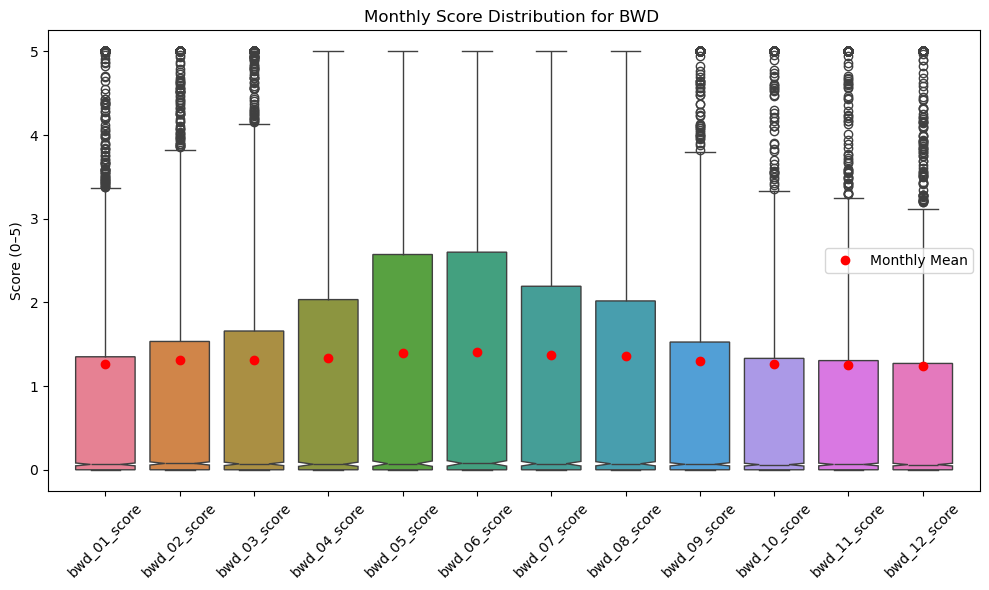

C:\Users\katik\AppData\Local\Temp\ipykernel_46948\1767162273.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  valid_scores = data[score_months].applymap(lambda x: x if (pd.notna(x) and 0 <= x <= 5) else np.nan)


Displaying Monthly Score Distribution for IAV...


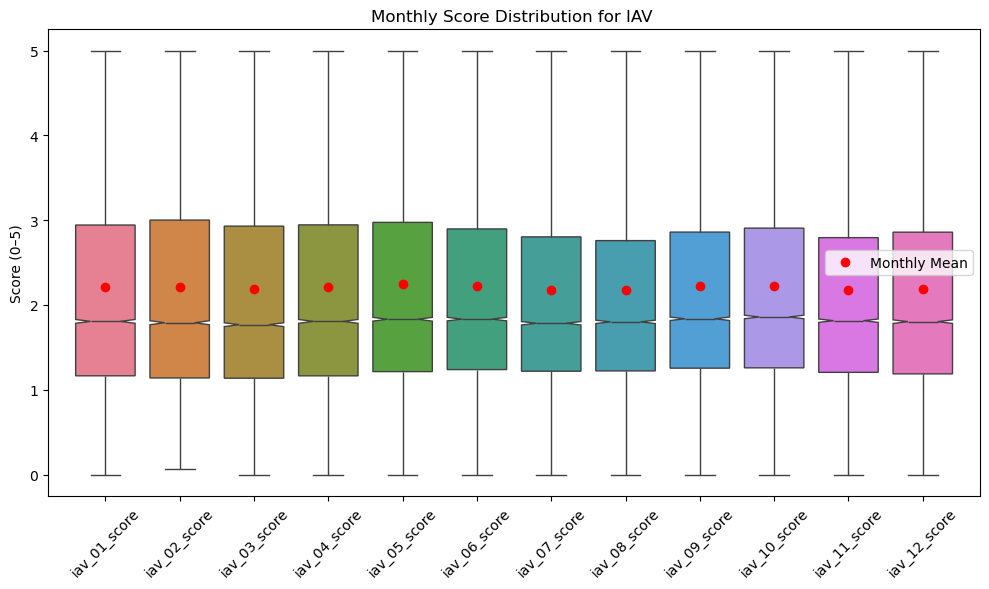

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd  # Ensure this is imported

for ind in ['bws', 'bwd', 'iav']:
    score_months = [f'{ind}_{str(i).zfill(2)}_score' for i in range(1, 13)]
    valid_scores = data[score_months].applymap(lambda x: x if (pd.notna(x) and 0 <= x <= 5) else np.nan)
    
    print(f"Displaying Monthly Score Distribution for {ind.upper()}...")
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=valid_scores, showfliers=True, notch=True)
    plt.title(f'Monthly Score Distribution for {ind.upper()} ')
    plt.ylabel('Score (0–5)')
    plt.xticks(rotation=45)
    
    means = valid_scores.mean()
    plt.plot(range(len(means)), means, color='red', marker='o', linestyle='', label='Monthly Mean')
    plt.legend()
    plt.tight_layout()
    plt.show()
    # Optionally, save each figure
    # plt.savefig(f"{ind}_monthly_score_boxplot.png")


In [70]:

data = pd.read_csv("C:/Users/katik/Downloads/Aqueduct40_baseline_monthly_y2023m07d05.csv")

# Abbreviation full forms
abbr_full = {
    "bws": "Baseline_Water_Stress",
    "bwd": "Baseline_Water_Depletion",
    "iav": "Interannual_Variability"
}
# Suffixes explained
suffix_dict = {
    "raw": "Raw_Value",
    "score": "Score",
    "cat": "Category",
    "label": "Label"
}

# Build mapping
col_fullforms = {}
for abbr in abbr_full:
    for month in range(1, 13):
        month_str = f"{month:02d}"
        for suffix in suffix_dict:
            col = f"{abbr}_{month_str}_{suffix}"
            col_full = f"{abbr_full[abbr]} (Month {month}) - {suffix_dict[suffix]}"
            col_fullforms[col] = col_full

# pfaf_id special case
col_fullforms["pfaf_id"] = "Pfafstetter_ID"

# Rename columns using mapping
data.rename(columns=col_fullforms, inplace=True)

# Save to new CSV (optional)
data.to_csv("Aqueduct_monthly_data.csv", index=False)


In [71]:
data.head(10)

,Pfafstetter_ID,Baseline_Water_Stress (Month 1) - Raw_Value,Baseline_Water_Stress (Month 1) - Score,Baseline_Water_Stress (Month 1) - Category,Baseline_Water_Stress (Month 1) - Label,Baseline_Water_Depletion (Month 1) - Raw_Value,Baseline_Water_Depletion (Month 1) - Score,Baseline_Water_Depletion (Month 1) - Category,Baseline_Water_Depletion (Month 1) - Label,Interannual_Variability (Month 1) - Raw_Value,Interannual_Variability (Month 1) - Score,Interannual_Variability (Month 1) - Category,Interannual_Variability (Month 1) - Label,Baseline_Water_Stress (Month 2) - Raw_Value,Baseline_Water_Stress (Month 2) - Score,Baseline_Water_Stress (Month 2) - Category,Baseline_Water_Stress (Month 2) - Label,Baseline_Water_Depletion (Month 2) - Raw_Value,Baseline_Water_Depletion (Month 2) - Score,Baseline_Water_Depletion (Month 2) - Category,Baseline_Water_Depletion (Month 2) - Label,Interannual_Variability (Month 2) - Raw_Value,Interannual_Variability (Month 2) - Score,Interannual_Variability (Month 2) - Category,Interannual_Variability (Month 2) - Label,Baseline_Water_Stress (Month 3) - Raw_Value,Baseline_Water_Stress (Month 3) - Score,Baseline_Water_Stress (Month 3) - Category,Baseline_Water_Stress (Month 3) - Label,Baseline_Water_Depletion (Month 3) - Raw_Value,Baseline_Water_Depletion (Month 3) - Score,Baseline_Water_Depletion (Month 3) - Category,Baseline_Water_Depletion (Month 3) - Label,Interannual_Variability (Month 3) - Raw_Value,Interannual_Variability (Month 3) - Score,Interannual_Variability (Month 3) - Category,Interannual_Variability (Month 3) - Label,Baseline_Water_Stress (Month 4) - Raw_Value,Baseline_Water_Stress (Month 4) - Score,Baseline_Water_Stress (Month 4) - Category,Baseline_Water_Stress (Month 4) - Label,Baseline_Water_Depletion (Month 4) - Raw_Value,Baseline_Water_Depletion (Month 4) - Score,Baseline_Water_Depletion (Month 4) - Category,Baseline_Water_Depletion (Month 4) - Label,Interannual_Variability (Month 4) - Raw_Value,Interannual_Variability (Month 4) - Score,Interannual_Variability (Month 4) - Category,Interannual_Variability (Month 4) - Label,Baseline_Water_Stress (Month 5) - Raw_Value,Baseline_Water_Stress (Month 5) - Score,Baseline_Water_Stress (Month 5) - Category,Baseline_Water_Stress (Month 5) - Label,Baseline_Water_Depletion (Month 5) - Raw_Value,Baseline_Water_Depletion (Month 5) - Score,Baseline_Water_Depletion (Month 5) - Category,Baseline_Water_Depletion (Month 5) - Label,Interannual_Variability (Month 5) - Raw_Value,Interannual_Variability (Month 5) - Score,Interannual_Variability (Month 5) - Category,Interannual_Variability (Month 5) - Label,Baseline_Water_Stress (Month 6) - Raw_Value,Baseline_Water_Stress (Month 6) - Score,Baseline_Water_Stress (Month 6) - Category,Baseline_Water_Stress (Month 6) - Label,Baseline_Water_Depletion (Month 6) - Raw_Value,Baseline_Water_Depletion (Month 6) - Score,Baseline_Water_Depletion (Month 6) - Category,Baseline_Water_Depletion (Month 6) - Label,Interannual_Variability (Month 6) - Raw_Value,Interannual_Variability (Month 6) - Score,Interannual_Variability (Month 6) - Category,Interannual_Variability (Month 6) - Label,Baseline_Water_Stress (Month 7) - Raw_Value,Baseline_Water_Stress (Month 7) - Score,Baseline_Water_Stress (Month 7) - Category,Baseline_Water_Stress (Month 7) - Label,Baseline_Water_Depletion (Month 7) - Raw_Value,Baseline_Water_Depletion (Month 7) - Score,Baseline_Water_Depletion (Month 7) - Category,Baseline_Water_Depletion (Month 7) - Label,Interannual_Variability (Month 7) - Raw_Value,Interannual_Variability (Month 7) - Score,Interannual_Variability (Month 7) - Category,Interannual_Variability (Month 7) - Label,Baseline_Water_Stress (Month 8) - Raw_Value,Baseline_Water_Stress (Month 8) - Score,Baseline_Water_Stress (Month 8) - Category,Baseline_Water_Stress (Month 8) - Label,Baseline_Water_Depletion (Month 8) - Raw_Value,Baseline_Water_Depletion (Month 8) - Score,Baseline_Water_Depletion (Month 8) - Category,Baseline_Water_Depletion (Month 8)

In [72]:
# Setting options to display all rows and columns
#pd.set_option('display.max_rows', None)
#pd.set_option('display.max_columns', None)

# Print the full list of columns
#print(data.columns.tolist())

In [73]:
import re
def clean_name(name):
    # Accepts only uppercase, numbers, and underscores
    return bool(re.match(r'^[A-Z0-9_]+$', name))

# Building a summary DataFrame
column_overview = pd.DataFrame({
    'Abbreviation': data.columns,
    'Has Nulls': [data[col].isnull().any() for col in data.columns],
    'Null Count': [data[col].isnull().sum() for col in data.columns],
    'Unique Count': [data[col].nunique() for col in data.columns],
    'Data Type': [data[col].dtype for col in data.columns],
    'Sample Value': [data[col].dropna().sample(1).values[0] if data[col].dropna().shape[0]>0 else None for col in data.columns],
    'Clean Name': [clean_name(col) for col in data.columns]
})


print(column_overview.head())


                                  Abbreviation  Has Nulls  Null Count  \
0                               Pfafstetter_ID      False           0   
1  Baseline_Water_Stress (Month 1) - Raw_Value      False           0   
2      Baseline_Water_Stress (Month 1) - Score      False           0   
3   Baseline_Water_Stress (Month 1) - Category      False           0   
4      Baseline_Water_Stress (Month 1) - Label      False           0   

   Unique Count Data Type           Sample Value  Clean Name  
0         15833     int64                 565540       False  
1         12254   float64               0.000051       False  
2          2411   float64               2.454247       False  
3             6   float64                    0.0       False  
4             6    object  Extremely High (>80%)       False  


In [74]:
import re
def clean_column_name(name):
    name = name.upper()
    # Replacing anything that's not A-Z, 0-9, _, %, (, ) with underscore
    name = re.sub(r'[^A-Z0-9%_()]', '_', name)
    # Reducing multiple underscores to single underscore
    name = re.sub(r'__+', '_', name)
    # Strip leading/trailing underscores
    name = name.strip('_')
    return name

# Clean all column names in your DataFrame
data.columns = [clean_column_name(c) for c in data.columns]

#Printing new column names
print(data.columns)



Index(['PFAFSTETTER_ID', 'BASELINE_WATER_STRESS_(MONTH_1)_RAW_VALUE',
       'BASELINE_WATER_STRESS_(MONTH_1)_SCORE',
       'BASELINE_WATER_STRESS_(MONTH_1)_CATEGORY',
       'BASELINE_WATER_STRESS_(MONTH_1)_LABEL',
       'BASELINE_WATER_DEPLETION_(MONTH_1)_RAW_VALUE',
       'BASELINE_WATER_DEPLETION_(MONTH_1)_SCORE',
       'BASELINE_WATER_DEPLETION_(MONTH_1)_CATEGORY',
       'BASELINE_WATER_DEPLETION_(MONTH_1)_LABEL',
       'INTERANNUAL_VARIABILITY_(MONTH_1)_RAW_VALUE',
       ...
       'BASELINE_WATER_STRESS_(MONTH_12)_CATEGORY',
       'BASELINE_WATER_STRESS_(MONTH_12)_LABEL',
       'BASELINE_WATER_DEPLETION_(MONTH_12)_RAW_VALUE',
       'BASELINE_WATER_DEPLETION_(MONTH_12)_SCORE',
       'BASELINE_WATER_DEPLETION_(MONTH_12)_CATEGORY',
       'BASELINE_WATER_DEPLETION_(MONTH_12)_LABEL',
       'INTERANNUAL_VARIABILITY_(MONTH_12)_RAW_VALUE',
       'INTERANNUAL_VARIABILITY_(MONTH_12)_SCORE',
       'INTERANNUAL_VARIABILITY_(MONTH_12)_CATEGORY',
       'INTERANNUAL_VARIABILITY

In [75]:
#Look for duplicates:
print(data.duplicated().sum())


1


In [76]:
#Check basic stats (min, max, mean, std, outliers):
print(data.describe(include='all').T)


                                                 count unique  \
PFAFSTETTER_ID                                 15834.0    NaN   
BASELINE_WATER_STRESS_(MONTH_1)_RAW_VALUE      15834.0    NaN   
BASELINE_WATER_STRESS_(MONTH_1)_SCORE          15834.0    NaN   
BASELINE_WATER_STRESS_(MONTH_1)_CATEGORY       15834.0    NaN   
BASELINE_WATER_STRESS_(MONTH_1)_LABEL            15834      6   
BASELINE_WATER_DEPLETION_(MONTH_1)_RAW_VALUE   15834.0    NaN   
BASELINE_WATER_DEPLETION_(MONTH_1)_SCORE       15834.0    NaN   
BASELINE_WATER_DEPLETION_(MONTH_1)_CATEGORY    15834.0    NaN   
BASELINE_WATER_DEPLETION_(MONTH_1)_LABEL         15834      6   
INTERANNUAL_VARIABILITY_(MONTH_1)_RAW_VALUE    15834.0    NaN   
INTERANNUAL_VARIABILITY_(MONTH_1)_SCORE        15834.0    NaN   
INTERANNUAL_VARIABILITY_(MONTH_1)_CATEGORY     15834.0    NaN   
INTERANNUAL_VARIABILITY_(MONTH_1)_LABEL          15834      6   
BASELINE_WATER_STRESS_(MONTH_2)_RAW_VALUE      15834.0    NaN   
BASELINE_WATER_STRESS_(MO

In [77]:
#Visualize or summarize missingness:
print(data.isnull().sum())



PFAFSTETTER_ID                                   0
BASELINE_WATER_STRESS_(MONTH_1)_RAW_VALUE        0
BASELINE_WATER_STRESS_(MONTH_1)_SCORE            0
BASELINE_WATER_STRESS_(MONTH_1)_CATEGORY         0
BASELINE_WATER_STRESS_(MONTH_1)_LABEL            0
BASELINE_WATER_DEPLETION_(MONTH_1)_RAW_VALUE     0
BASELINE_WATER_DEPLETION_(MONTH_1)_SCORE         0
BASELINE_WATER_DEPLETION_(MONTH_1)_CATEGORY      0
BASELINE_WATER_DEPLETION_(MONTH_1)_LABEL         0
INTERANNUAL_VARIABILITY_(MONTH_1)_RAW_VALUE      0
INTERANNUAL_VARIABILITY_(MONTH_1)_SCORE          0
INTERANNUAL_VARIABILITY_(MONTH_1)_CATEGORY       0
INTERANNUAL_VARIABILITY_(MONTH_1)_LABEL          0
BASELINE_WATER_STRESS_(MONTH_2)_RAW_VALUE        0
BASELINE_WATER_STRESS_(MONTH_2)_SCORE            0
BASELINE_WATER_STRESS_(MONTH_2)_CATEGORY         0
BASELINE_WATER_STRESS_(MONTH_2)_LABEL            0
BASELINE_WATER_DEPLETION_(MONTH_2)_RAW_VALUE     0
BASELINE_WATER_DEPLETION_(MONTH_2)_SCORE         0
BASELINE_WATER_DEPLETION_(MONTH

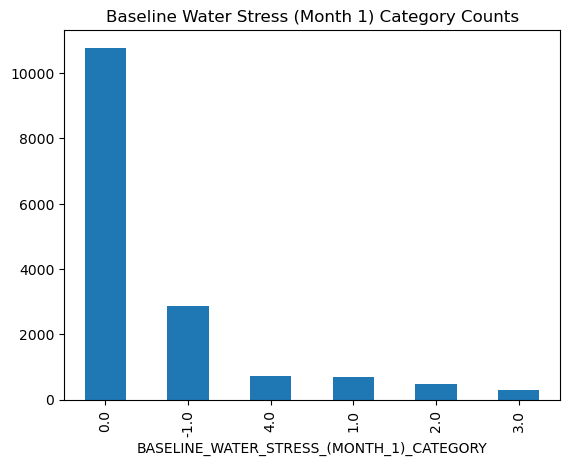

In [78]:
import matplotlib.pyplot as plt
data['BASELINE_WATER_STRESS_(MONTH_1)_CATEGORY'].value_counts().plot(kind='bar')
plt.title('Baseline Water Stress (Month 1) Category Counts')
plt.show()


In [79]:
#removing duplicates
data = data.drop_duplicates()


In [80]:
#Replacing Fill Values with np.nan (missing):
import numpy as np
data = data.replace([-9999, 9999, -9999.0, 9999.0], np.nan)


In [81]:
# Count missing values per column, sorted by most missing
missing_per_col = data.isnull().sum().sort_values(ascending=False)
print(missing_per_col)

# Proportion missing per column
missing_frac = (data.isnull().sum() / len(data)).sort_values(ascending=False)
print(missing_frac)

BASELINE_WATER_STRESS_(MONTH_9)_RAW_VALUE        493
BASELINE_WATER_DEPLETION_(MONTH_9)_RAW_VALUE     493
BASELINE_WATER_STRESS_(MONTH_8)_RAW_VALUE        455
BASELINE_WATER_DEPLETION_(MONTH_8)_RAW_VALUE     455
BASELINE_WATER_DEPLETION_(MONTH_10)_RAW_VALUE    450
BASELINE_WATER_STRESS_(MONTH_10)_RAW_VALUE       450
BASELINE_WATER_STRESS_(MONTH_2)_RAW_VALUE        447
BASELINE_WATER_DEPLETION_(MONTH_2)_RAW_VALUE     447
BASELINE_WATER_STRESS_(MONTH_6)_RAW_VALUE        435
BASELINE_WATER_DEPLETION_(MONTH_6)_RAW_VALUE     435
BASELINE_WATER_DEPLETION_(MONTH_5)_RAW_VALUE     426
BASELINE_WATER_STRESS_(MONTH_5)_RAW_VALUE        426
BASELINE_WATER_DEPLETION_(MONTH_3)_RAW_VALUE     419
BASELINE_WATER_STRESS_(MONTH_3)_RAW_VALUE        419
BASELINE_WATER_STRESS_(MONTH_4)_RAW_VALUE        418
BASELINE_WATER_DEPLETION_(MONTH_4)_RAW_VALUE     418
BASELINE_WATER_STRESS_(MONTH_11)_RAW_VALUE       414
BASELINE_WATER_DEPLETION_(MONTH_11)_RAW_VALUE    414
BASELINE_WATER_DEPLETION_(MONTH_1)_RAW_VALUE  

In [82]:
#Median Imputation for Numeric Columns (Best for Climate Data)
# Impute only columns with missing values using the median
missing_cols = [c for c in data.columns if data[c].isnull().any() and data[c].dtype in ['float64', 'int64']]
data[missing_cols] = data[missing_cols].fillna(data[missing_cols].median())


In [83]:
#Mode Imputation for Categorical Columns
categorical_missing_cols = [c for c in data.columns if data[c].isnull().any() and data[c].dtype == 'object']
for col in categorical_missing_cols:
    data[col] = data[col].fillna(data[col].mode()[0])


In [84]:
print(data.isnull().sum().sort_values(ascending=False))


PFAFSTETTER_ID                                   0
BASELINE_WATER_STRESS_(MONTH_7)_RAW_VALUE        0
INTERANNUAL_VARIABILITY_(MONTH_8)_RAW_VALUE      0
INTERANNUAL_VARIABILITY_(MONTH_8)_SCORE          0
INTERANNUAL_VARIABILITY_(MONTH_8)_CATEGORY       0
INTERANNUAL_VARIABILITY_(MONTH_8)_LABEL          0
BASELINE_WATER_STRESS_(MONTH_9)_RAW_VALUE        0
BASELINE_WATER_STRESS_(MONTH_9)_SCORE            0
BASELINE_WATER_STRESS_(MONTH_9)_CATEGORY         0
BASELINE_WATER_STRESS_(MONTH_9)_LABEL            0
BASELINE_WATER_DEPLETION_(MONTH_9)_RAW_VALUE     0
BASELINE_WATER_DEPLETION_(MONTH_9)_SCORE         0
BASELINE_WATER_DEPLETION_(MONTH_9)_CATEGORY      0
BASELINE_WATER_DEPLETION_(MONTH_9)_LABEL         0
INTERANNUAL_VARIABILITY_(MONTH_9)_RAW_VALUE      0
INTERANNUAL_VARIABILITY_(MONTH_9)_SCORE          0
INTERANNUAL_VARIABILITY_(MONTH_9)_CATEGORY       0
BASELINE_WATER_DEPLETION_(MONTH_8)_LABEL         0
BASELINE_WATER_DEPLETION_(MONTH_8)_CATEGORY      0
BASELINE_WATER_DEPLETION_(MONTH

In [85]:

import numpy as np

summary = {}

# 1. Shape of the data
summary['Rows'], summary['Columns'] = data.shape

# 2. Duplicates
summary['Duplicate Rows'] = data.duplicated().sum()

# 3. Nulls per Column & Fraction Missing
summary['Total Missing (nulls)'] = data.isnull().sum().sum()
summary['Columns with Missing'] = (data.isnull().sum() > 0).sum()
summary['Missing Values by Column'] = data.isnull().sum()
summary['Fraction Missing by Column'] = data.isnull().mean()

# 4. Columns with 100% missing
summary['Columns all missing'] = list(data.columns[data.isnull().mean() == 1])

# 5. Columns with High Cardinality or Single Value
summary['Columns with 1 Unique Value'] = [col for col in data if data[col].nunique() == 1]
summary['Columns with High Cardinality (>95% unique)'] = [col for col in data if data[col].nunique()/len(data) > 0.95]

# 6. Basic Numeric Stats
numeric_stats = data.describe(include=[np.number]).T

# 7. Basic Object (Categorical) Stats
object_stats = data.describe(include=['object']).T

# Print output
for k, v in summary.items():
    print(f"--- {k} ---")
    print(v)
    print()

print("--- Numeric Stats (first 5 rows) ---")
print(numeric_stats.head())

print("--- Object/Categorical Stats (first 5 rows) ---")
print(object_stats.head())


--- Rows ---
15833

--- Columns ---
145

--- Duplicate Rows ---
0

--- Total Missing (nulls) ---
0

--- Columns with Missing ---
0

--- Missing Values by Column ---
PFAFSTETTER_ID                                   0
BASELINE_WATER_STRESS_(MONTH_1)_RAW_VALUE        0
BASELINE_WATER_STRESS_(MONTH_1)_SCORE            0
BASELINE_WATER_STRESS_(MONTH_1)_CATEGORY         0
BASELINE_WATER_STRESS_(MONTH_1)_LABEL            0
BASELINE_WATER_DEPLETION_(MONTH_1)_RAW_VALUE     0
BASELINE_WATER_DEPLETION_(MONTH_1)_SCORE         0
BASELINE_WATER_DEPLETION_(MONTH_1)_CATEGORY      0
BASELINE_WATER_DEPLETION_(MONTH_1)_LABEL         0
INTERANNUAL_VARIABILITY_(MONTH_1)_RAW_VALUE      0
INTERANNUAL_VARIABILITY_(MONTH_1)_SCORE          0
INTERANNUAL_VARIABILITY_(MONTH_1)_CATEGORY       0
INTERANNUAL_VARIABILITY_(MONTH_1)_LABEL          0
BASELINE_WATER_STRESS_(MONTH_2)_RAW_VALUE        0
BASELINE_WATER_STRESS_(MONTH_2)_SCORE            0
BASELINE_WATER_STRESS_(MONTH_2)_CATEGORY         0
BASELINE_WATER_STRE

In [91]:
import pandas as pd
import re

# Suppose df is your DataFrame

def rename_month_columns(cols):
    months = ['JANUARY', 'FEBRUARY', 'MARCH', 'APRIL', 'MAY', 'JUNE',
              'JULY', 'AUGUST', 'SEPTEMBER', 'OCTOBER', 'NOVEMBER', 'DECEMBER']
    def repl(match):
        idx = int(match.group(1))-1
        return months[idx] if 0 <= idx < 12 else match.group(0)
    return [re.sub(r'MONTH_(\d{1,2})', repl, c) for c in cols]

data.columns = rename_month_columns(data.columns)
print(data.columns)


Index(['PFAFSTETTER_ID', 'BASELINE_WATER_STRESS_(JANUARY)_RAW_VALUE',
       'BASELINE_WATER_STRESS_(JANUARY)_SCORE',
       'BASELINE_WATER_STRESS_(JANUARY)_CATEGORY',
       'BASELINE_WATER_STRESS_(JANUARY)_LABEL',
       'BASELINE_WATER_DEPLETION_(JANUARY)_RAW_VALUE',
       'BASELINE_WATER_DEPLETION_(JANUARY)_SCORE',
       'BASELINE_WATER_DEPLETION_(JANUARY)_CATEGORY',
       'BASELINE_WATER_DEPLETION_(JANUARY)_LABEL',
       'INTERANNUAL_VARIABILITY_(JANUARY)_RAW_VALUE',
       ...
       'BASELINE_WATER_STRESS_(DECEMBER)_CATEGORY',
       'BASELINE_WATER_STRESS_(DECEMBER)_LABEL',
       'BASELINE_WATER_DEPLETION_(DECEMBER)_RAW_VALUE',
       'BASELINE_WATER_DEPLETION_(DECEMBER)_SCORE',
       'BASELINE_WATER_DEPLETION_(DECEMBER)_CATEGORY',
       'BASELINE_WATER_DEPLETION_(DECEMBER)_LABEL',
       'INTERANNUAL_VARIABILITY_(DECEMBER)_RAW_VALUE',
       'INTERANNUAL_VARIABILITY_(DECEMBER)_SCORE',
       'INTERANNUAL_VARIABILITY_(DECEMBER)_CATEGORY',
       'INTERANNUAL_VARIABILITY

In [92]:
# Setting options to display all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Print the full list of columns
print(data.columns.tolist())

['PFAFSTETTER_ID', 'BASELINE_WATER_STRESS_(JANUARY)_RAW_VALUE', 'BASELINE_WATER_STRESS_(JANUARY)_SCORE', 'BASELINE_WATER_STRESS_(JANUARY)_CATEGORY', 'BASELINE_WATER_STRESS_(JANUARY)_LABEL', 'BASELINE_WATER_DEPLETION_(JANUARY)_RAW_VALUE', 'BASELINE_WATER_DEPLETION_(JANUARY)_SCORE', 'BASELINE_WATER_DEPLETION_(JANUARY)_CATEGORY', 'BASELINE_WATER_DEPLETION_(JANUARY)_LABEL', 'INTERANNUAL_VARIABILITY_(JANUARY)_RAW_VALUE', 'INTERANNUAL_VARIABILITY_(JANUARY)_SCORE', 'INTERANNUAL_VARIABILITY_(JANUARY)_CATEGORY', 'INTERANNUAL_VARIABILITY_(JANUARY)_LABEL', 'BASELINE_WATER_STRESS_(FEBRUARY)_RAW_VALUE', 'BASELINE_WATER_STRESS_(FEBRUARY)_SCORE', 'BASELINE_WATER_STRESS_(FEBRUARY)_CATEGORY', 'BASELINE_WATER_STRESS_(FEBRUARY)_LABEL', 'BASELINE_WATER_DEPLETION_(FEBRUARY)_RAW_VALUE', 'BASELINE_WATER_DEPLETION_(FEBRUARY)_SCORE', 'BASELINE_WATER_DEPLETION_(FEBRUARY)_CATEGORY', 'BASELINE_WATER_DEPLETION_(FEBRUARY)_LABEL', 'INTERANNUAL_VARIABILITY_(FEBRUARY)_RAW_VALUE', 'INTERANNUAL_VARIABILITY_(FEBRUARY)_SC

In [93]:
# Save cleaned dataframe to CSV
data.to_csv('Aqueduct_monthly_data_cleaned.csv', index=False)
